# CS 640 - 2025 Fall - Homework 7

In this homework, you will train a policy to control a cat that wants to move towards a fish.
This homework generalizes previous homeworks controlling the cat to a continuous space including velocity, but keeps discrete actions.

## Instructions

1. Follow the instructions below to construct and optimize the policy.
2. Run all the cells before submitting.
3. Submit your notebook in Gradescope.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch

## Cat State

The cats have the same four actions as before, but now have continuous positions and velocities.
Additionally, the velocity is capped at one and the position updates are noisy.

In [2]:
# DO NOT CHANGE

CAT_ACTIONS = {"up": (0, 1), "down" : (0, -1), "left" : (-1, 0), "right": (1, 0)}

class CatState:
    def __init__(self, x, y, vx, vy):
        self.x = x
        self.y = y
        self.vx = vx
        self.vy = vy

    def __repr__(self):
        d = self.distance_to_fish()
        return f"CatState(x={self.x:+.2f}, y={self.y:+.2f}, vx={self.vx:+.2f}, vy={self.vy:+.2f}, distance to fish={d:.2f})"

    def act(self, action):
        dvx, dvy = CAT_ACTIONS[action]

        new_vx = self.vx + dvx
        new_vy = self.vx + dvy
        v = np.sqrt(new_vx**2 + new_vy**2)

        if v > 1:
            new_vx /= v
            new_vy /= v

        new_x = self.x + self.vx + np.random.normal(0, 0.1)
        new_y = self.y + self.vy + np.random.normal(0, 0.1)

        new_state = CatState(new_x, new_y, new_vx, new_vy)

        reward = 1 if self.distance_to_fish() <= 5 else 0

        return (reward, new_state)

    def distance_to_fish(self):
        return np.sqrt((self.x-8)**2 + (self.y - 0)**2)

c0 = CatState(0, 0, 0, 0)
c0

CatState(x=+0.00, y=+0.00, vx=+0.00, vy=+0.00, distance to fish=8.00)

### Uniform Random Cat Walks

In [3]:
# YOUR CHANGES HERE

def uniform_random_walk(initial_state, num_steps):
    current_state = initial_state
    states = [current_state]
    rewards = []

    for _ in range(num_steps):
        action = np.random.choice(list(CAT_ACTIONS.keys()))
        reward, next_state = current_state.act(action)
        states.append(next_state)
        rewards.append(reward)
        current_state = next_state

    return states, rewards

# Example usage:
initial_state = CatState(0, 0, 0, 0)
states, rewards = uniform_random_walk(initial_state, 10)

print("States:")
for state in states:
    print(state)

print("\nRewards:")
print(rewards)

States:
CatState(x=+0.00, y=+0.00, vx=+0.00, vy=+0.00, distance to fish=8.00)
CatState(x=-0.11, y=+0.09, vx=+0.00, vy=-1.00, distance to fish=8.11)
CatState(x=-0.10, y=-0.81, vx=+0.00, vy=-1.00, distance to fish=8.14)
CatState(x=-0.27, y=-1.87, vx=-1.00, vy=+0.00, distance to fish=8.48)
CatState(x=-1.12, y=-1.72, vx=-0.45, vy=-0.89, distance to fish=9.28)
CatState(x=-1.57, y=-2.67, vx=-0.45, vy=+0.55, distance to fish=9.94)
CatState(x=-2.05, y=-2.13, vx=+0.55, vy=-0.45, distance to fish=10.27)
CatState(x=-1.44, y=-2.44, vx=-0.45, vy=+0.55, distance to fish=9.75)
CatState(x=-1.84, y=-1.95, vx=-0.45, vy=+0.55, distance to fish=10.03)
CatState(x=-2.31, y=-1.47, vx=-0.30, vy=-0.96, distance to fish=10.41)
CatState(x=-2.62, y=-2.38, vx=-0.30, vy=+0.70, distance to fish=10.88)

Rewards:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


## Optimize a Policy

You will optimize the following policy to maximize the cat's rewards.

In [4]:
# DO NOT CHANGE

CAT_ACTION_ORDER = ["up", "down", "left", "right"]

class ShallowPolicy(torch.nn.Module):
    def __init__(self, input_size=4, hidden_size=128, output_size=4):
        super().__init__()

        self.fc_1 = torch.nn.Linear(input_size, hidden_size)
        self.fc_2 = torch.nn.Linear(hidden_size, output_size)

        self.relu = torch.nn.ReLU()
        self.softmax = torch.nn.Softmax(dim=0)

    def forward(self, x):
        logits = self.fc_2(self.relu(self.fc_1(x)))
        # print("LOGITS", logits)
        return self.softmax(logits)

pi = ShallowPolicy()

### Construct input tensors.

Fill in the function below to construct an appropriate tensor from a cat state to pass into the policy.

In [5]:
# YOUR CHANGES HERE

def compute_state_tensor(state):
  """Converts a CatState object to a PyTorch tensor."""
  return torch.tensor([state.x, state.y, state.vx, state.vy], dtype=torch.float32)

### Test your tensor conversion.

In [6]:
# DO NOT CHANGE

compute_state_tensor(c0)

tensor([0., 0., 0., 0.])

In [7]:
# DO NOT CHANGE

compute_state_tensor(CatState(1, 2, 3, 4))

tensor([1., 2., 3., 4.])

### Write a function using a policy to pick an action for the state.

In [8]:
def pick_action(policy, s):
    # YOUR CHANGES HERE
    state_tensor = compute_state_tensor(s)
    action_probs = policy(state_tensor)
    action_index = torch.multinomial(action_probs, 1).item()
    action = CAT_ACTION_ORDER[action_index]
    return action

### Test picking actions

Use the policy `pi` to pick 10 actions starting from the initial state `c0`.

Log each action in the following format.
```
ACTION down STATE CatState(x=+0.09, y=+0.07, vx=+0.00, vy=-1.00, distance to fish=7.91)
```

In [9]:
# YOUR CHANGES HERE

current_state = c0
for _ in range(10):
    action = pick_action(pi, current_state)
    reward, next_state = current_state.act(action)
    print(f"ACTION {action} STATE {next_state}")
    current_state = next_state

ACTION down STATE CatState(x=+0.03, y=-0.18, vx=+0.00, vy=-1.00, distance to fish=7.97)
ACTION right STATE CatState(x=+0.13, y=-1.22, vx=+1.00, vy=+0.00, distance to fish=7.96)
ACTION down STATE CatState(x=+0.97, y=-1.10, vx=+1.00, vy=+0.00, distance to fish=7.12)
ACTION up STATE CatState(x=+1.84, y=-1.10, vx=+0.45, vy=+0.89, distance to fish=6.26)
ACTION up STATE CatState(x=+2.23, y=-0.14, vx=+0.30, vy=+0.96, distance to fish=5.77)
ACTION left STATE CatState(x=+2.41, y=+0.86, vx=-0.70, vy=+0.30, distance to fish=5.66)
ACTION left STATE CatState(x=+1.57, y=+1.20, vx=-0.92, vy=-0.38, distance to fish=6.54)
ACTION up STATE CatState(x=+0.56, y=+0.72, vx=-0.92, vy=+0.08, distance to fish=7.47)
ACTION down STATE CatState(x=-0.37, y=+0.74, vx=-0.43, vy=-0.90, distance to fish=8.41)
ACTION up STATE CatState(x=-0.91, y=-0.12, vx=-0.43, vy=+0.57, distance to fish=8.91)


## Implement the REINFORCE algorithm as covered in class.

Use 1000 episodes of 100 actions to train your policy to maximize total reward using the REINFORCE algorithm.
Save the total rewards for each episode to be plotted later.
Use $\gamma$ = 1.0 and $\alpha=0.001$.

During the REINFORCEMENT algorithm, if the selected action probability is zero, skip the parameter update.
This may happen due to parameter changes since the action was chosen.


In [10]:
# YOUR CHANGES HERE

optimizer = torch.optim.Adam(pi.parameters(), lr=0.001)
gamma = 1.0
num_episodes = 1000
num_steps_per_episode = 100
episode_rewards = []

for episode in range(num_episodes):
    current_state = CatState(0, 0, 0, 0)
    states = []
    actions = []
    rewards = []
    log_probs = []

    for step in range(num_steps_per_episode):
        state_tensor = compute_state_tensor(current_state)
        action_probs = pi(state_tensor)
        action = pick_action(pi, current_state)
        action_index = CAT_ACTION_ORDER.index(action)
        log_prob = torch.log(action_probs[action_index])

        reward, next_state = current_state.act(action)

        states.append(current_state)
        actions.append(action)
        rewards.append(reward)
        log_probs.append(log_prob)
        current_state = next_state

    episode_rewards.append(sum(rewards))

    # Calculate discounted rewards
    discounted_rewards = []
    R = 0
    for r in reversed(rewards):
        R = r + gamma * R
        discounted_rewards.insert(0, R)

    discounted_rewards = torch.tensor(discounted_rewards)
    # Standardize rewards (optional but often helpful)
    # discounted_rewards = (discounted_rewards - discounted_rewards.mean()) / (discounted_rewards.std() + 1e-9)

    # Calculate loss and update policy
    loss = []
    for log_prob, R in zip(log_probs, discounted_rewards):
        # Skip update if probability is zero
        if torch.exp(log_prob) > 0:
            loss.append(-log_prob * R)

    optimizer.zero_grad()
    if loss:
        torch.stack(loss).sum().backward()
        optimizer.step()

    if (episode + 1) % 100 == 0:
        print(f"Episode {episode+1}/{num_episodes}, Total Reward: {episode_rewards[-1]}")

Episode 100/1000, Total Reward: 75
Episode 200/1000, Total Reward: 34
Episode 300/1000, Total Reward: 92
Episode 400/1000, Total Reward: 68
Episode 500/1000, Total Reward: 76
Episode 600/1000, Total Reward: 79
Episode 700/1000, Total Reward: 93
Episode 800/1000, Total Reward: 14
Episode 900/1000, Total Reward: 92
Episode 1000/1000, Total Reward: 88


### Plot the rewards for each episode.

Use a scatter plot with appropriate alpha.

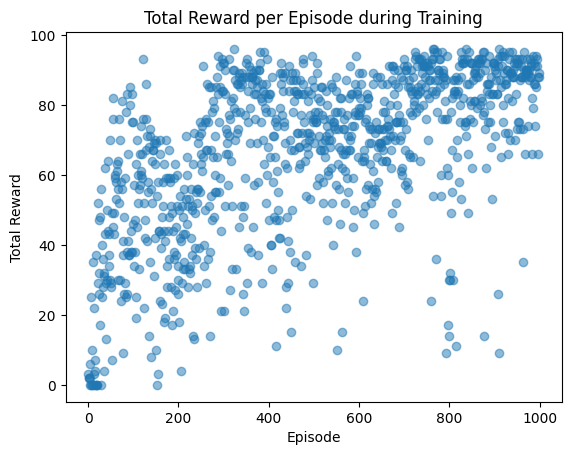

In [11]:
# YOUR CHANGES HERE

plt.scatter(range(num_episodes), episode_rewards, alpha=0.5)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Total Reward per Episode during Training")
plt.show()